In [1]:
PROJ_NAME = "kyber_indcca_dec_ttest"
LABEL = ""
OFFSET = 480000

In [2]:
import sys
sys.path.insert(0, "../")
from host.ttest_trace_collector import TTestTraceCollector

In [3]:
trace_collector = TTestTraceCollector(proj_name=PROJ_NAME, label=LABEL, input_len=32, output_len=0, offset=OFFSET)

In [4]:
trace_collector.init_target(force=False)

(ChipWhisperer NAEUSB WARNING|File naeusb.py:800) Your firmware (0.51) is outdated - latest is 0.53 See https://chipwhisperer.readthedocs.io/en/latest/firmware.html for more information


In [5]:
trace_collector.default_setup(40E6, 12, 24000, mul=4)

In [9]:
trace_collector.build_fw()
trace_collector.program_fw()

-DKYBER_K=3 -DSS_VER=1 -O3 -I../../../../fw/kyber_hw -I../victims_commons -I../../driver -I../../simpleserial -I../../../../sdk/lib -march=rv32im -mabi=ilp32 -mstrict-align -T ../../../../sdk/toolchain/linksc.ld -flto -ffunction-sections -fdata-sections -nostartfiles -o kyber_indcca_dec_ttest.elf
/opt/riscv/bin/riscv64-unknown-elf-gcc kyber_indcca_dec_ttest.c ../../../../fw/kyber_hw/indcpa.c ../../../../fw/kyber_hw/poly.c ../../../../fw/kyber_hw/polyvec.c ../../../../fw/kyber_hw/pack.c ../../../../fw/kyber_hw/symmetric.c ../../../../fw/kyber_hw/cbd.c ../../../../fw/kyber_hw/masked_indcpa.c ../../../../fw/kyber_hw/masked_poly.c ../../../../fw/kyber_hw/masked_polyvec.c ../../../../fw/kyber_hw/masked_symmetric.c ../../../../fw/kyber_hw/masked_cbd.c ../../../../fw/kyber_hw/masked_gadgets.c ../../../../fw/kyber_hw/kem.c ../../../../fw/kyber_hw/masked_kem.c ../../../../fw/kyber_hw/verify.c ../victims_commons/victims_commons_util.c ../victims_commons/victims_commons_kyber.c ../../driver/cw305

../fw/victims/kyber_indcca_dec_ttest/kyber_indcca_dec_ttest.inst.bin: 100%|██████████| 12.8k/12.8k [00:12<00:00, 1.01kB/s]
../fw/victims/kyber_indcca_dec_ttest/kyber_indcca_dec_ttest.data.bin:   0%|          | 0.00/2.60k [00:00<?, ?B/s]

File transmission complete for ../fw/victims/kyber_indcca_dec_ttest/kyber_indcca_dec_ttest.inst.bin.
Sending file: ../fw/victims/kyber_indcca_dec_ttest/kyber_indcca_dec_ttest.data.bin


../fw/victims/kyber_indcca_dec_ttest/kyber_indcca_dec_ttest.data.bin: 100%|██████████| 2.60k/2.60k [00:02<00:00, 971B/s]


File transmission complete for ../fw/victims/kyber_indcca_dec_ttest/kyber_indcca_dec_ttest.data.bin.
Program load complete.
Serial port closed.


# PRNG=OFF

In [10]:
trace_collector.collect_traces(N=1000, prng_off=True, overwrite=True, check_output=False, init_input=False, dummy_inbetween_1=True)

Capturing traces:   0%|          | 0/1000 [00:00<?, ?it/s]

(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 13
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 12


KeyboardInterrupt: 

In [29]:
ttest_analysis = trace_collector.get_analysis_obj(N=1000, prng_off=True)

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file traces/kyber_indcca_dec_ttest_N1000_prngoff1_r0_o360000_.ets with 1000 traces.
s................: float64

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file traces/kyber_indcca_dec_ttest_N1000_prngoff1_r1_o360000_.ets with 1000 traces.
s................: float64



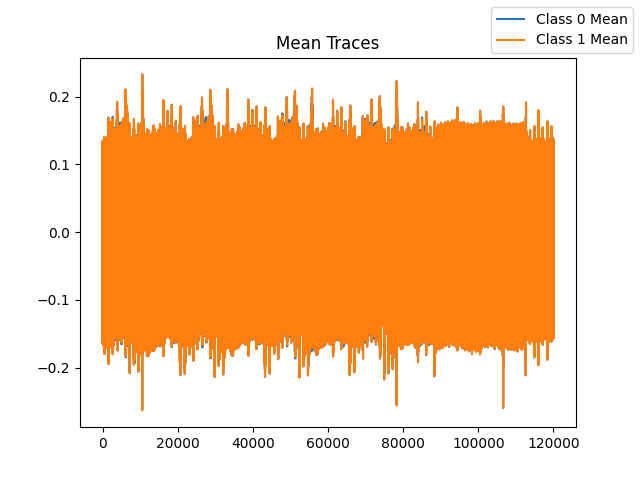

In [30]:
ttest_analysis.plot_means()

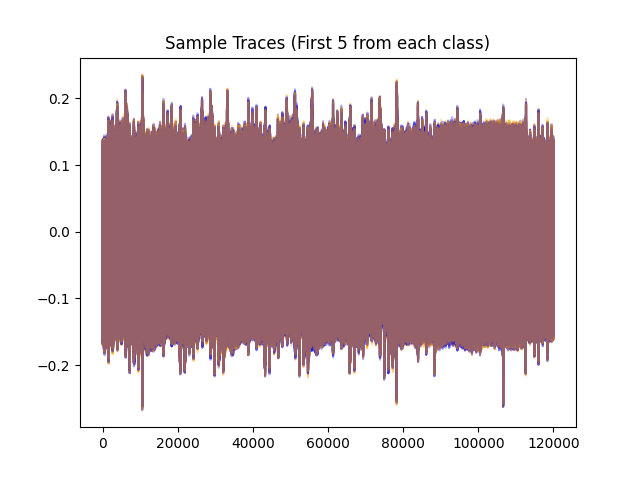

In [31]:
ttest_analysis.plot_traces()

In [32]:
ttest_analysis.run_ttest()

Running T-Test: 100%|██████████| 1/1 [00:01<00:00,  1.29s/it]


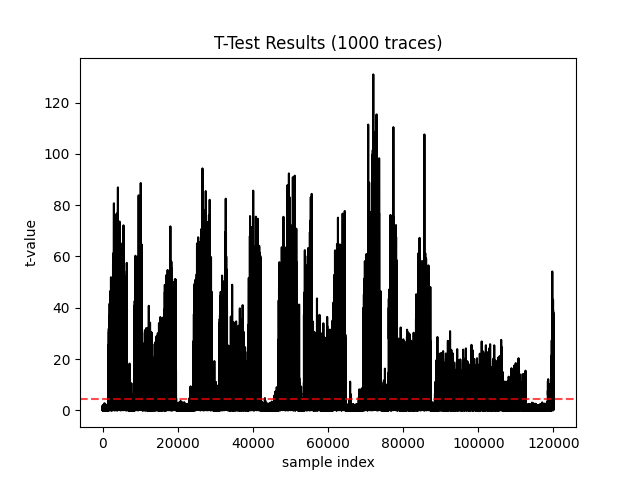

In [33]:
%matplotlib widget
ttest_analysis.plot_ttest()

# PRNG=ON

In [7]:
trace_collector.collect_traces(N=100000, prng_off=False, overwrite=True, check_output=False, init_input=False, dummy_inbetween_1=True)

Capturing traces:   0%|          | 0/100000 [00:00<?, ?it/s]

ERROR:estraces.formats.ets_writer:Exception raised during init of h5f file: [Errno 2] Unable to synchronously open file (unable to open file: name = 'traces/kyber_indcca_dec_ttest_N100000_prngoff0_r0_o480000_.ets', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0).
ERROR:estraces.formats.ets_writer:Exception raised during init of h5f file: [Errno 2] Unable to synchronously open file (unable to open file: name = 'traces/kyber_indcca_dec_ttest_N100000_prngoff0_r1_o480000_.ets', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0).


In [10]:
trace_collector.set_offset(360000)
trace_collector.collect_traces(N=100000, prng_off=False, overwrite=True, check_output=False, init_input=False, dummy_inbetween_1=True)

Capturing traces:   0%|          | 0/100000 [00:00<?, ?it/s]

ERROR:estraces.formats.ets_writer:Exception raised during init of h5f file: [Errno 2] Unable to synchronously open file (unable to open file: name = 'traces/kyber_indcca_dec_ttest_N100000_prngoff0_r0_o360000_.ets', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0).
ERROR:estraces.formats.ets_writer:Exception raised during init of h5f file: [Errno 2] Unable to synchronously open file (unable to open file: name = 'traces/kyber_indcca_dec_ttest_N100000_prngoff0_r1_o360000_.ets', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0).


In [ ]:
ttest_analysis = trace_collector.get_analysis_obj(N=10, prng_off=False)

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file traces/kyber_cpapke_dec_ttest_N10_prngoff0_r0_polymsg_removed with 10 traces.
s................: float64

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file traces/kyber_cpapke_dec_ttest_N10_prngoff0_r1_polymsg_removed with 10 traces.
s................: float64



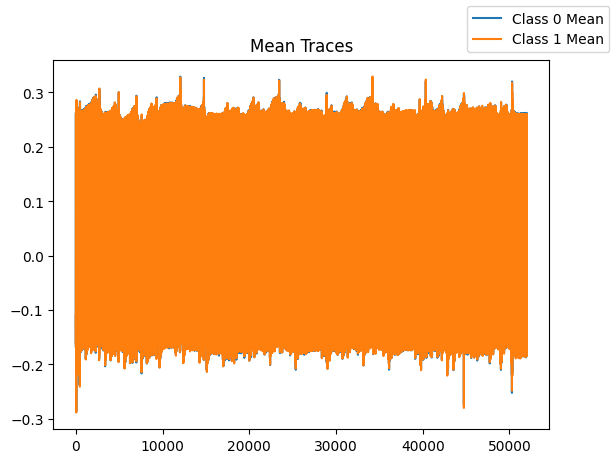

In [ ]:
ttest_analysis.plot_means()

In [ ]:
ttest_analysis.plot_traces()

In [ ]:
ttest_analysis.run_ttest()

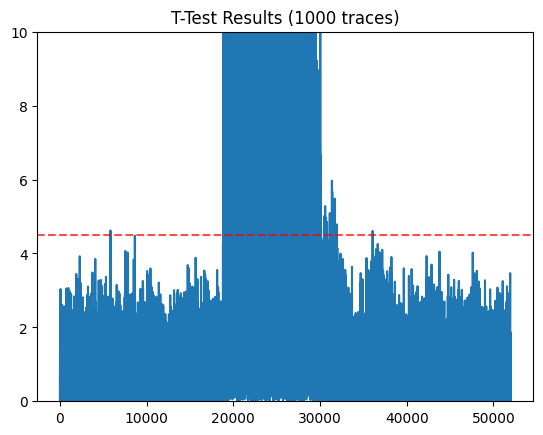

In [ ]:
ttest_analysis.plot_ttest(ylimit=10)